# Stonks — RTSM Course Notebook
### Regression Analysis & Time Series Models — Course 1 submission

*Author: Lavzit · Submission view of a shared codebase.*

## 1. Introduction

This notebook is the time-series-and-statistics view of a project I've been working through for two courses at once. Same codebase, same data, same models — but here I'm telling the story the way Brockwell & Davis and Shumway & Stoffer would tell it: stationarity first, ACF/PACF before any model order, residual diagnostics that are at least as long as the model summary, and an honest accounting of where classical methods run out of road. The AI/ML view (clustering, MLPs, LSTMs, BPTT) lives in `aiml/notebook.ipynb`.

**The data.** Daily OHLC + Adjusted Close from yfinance for seven Indian equities — two indices (NSEI, SENSEX) and five large-caps (TCS, HDFCBANK, RELIANCE, ITC, MARUTI) — over **2016-04-11 → 2026-04-10**, ~2,470 trading days. Sector spread (IT, banking, energy, FMCG, autos) plus the indices keeps the cross-sectional story interesting; ten years gets us COVID, the 2022 rate-hike cycle, and a couple of regular bull/bear rotations. RELIANCE is the deep-dive ticker because it's the most liquid name and has clean volatility clustering visible to the eye.

**Framing.** The point of this project is to *apply* what the course covered to real data and write up what worked and what didn't — not to build a production trading system. So when ARIMA collapses to a constant, when the regime detector finds only COVID, when the paper trader loses to buy-and-hold — those are findings, not failures. Honest negative results are doing their job in a learning project.

The heavy lifting lives in `scripts/01_eda.py` through `scripts/10_sentiment.py`. This notebook reads their outputs from `results/` rather than re-running them.


In [1]:
# Standard imports + a ROOT pointer so figure paths stay tidy.
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.float_format", lambda x: f"{x:.6g}")
pd.set_option("display.max_columns", 20)

ROOT = Path.cwd().parent if Path.cwd().name == "rtsm" else Path.cwd()
FIGURES = ROOT / "results" / "figures"
METRICS = ROOT / "results" / "metrics"
PROCESSED = ROOT / "data" / "processed"
ROOT, FIGURES.exists(), METRICS.exists()


(PosixPath('/home/anpenlibe/Stonks'), True, True)

## 2. Data & EDA

Before fitting anything I want to know what the data looks like and whether it satisfies the assumptions the classical models need. Brockwell & Davis Ch 1–2 sets the agenda: characterise the series, check stationarity, look at the autocorrelation structure. Shumway & Stoffer Ch 1 makes essentially the same opening move.

### 2.1 Price history

Seven tickers, ten years, normalised to 100 at the start so they're visually comparable. The COVID drawdown is unmistakable; the 2022 rate-hike cycle is visible if you squint.


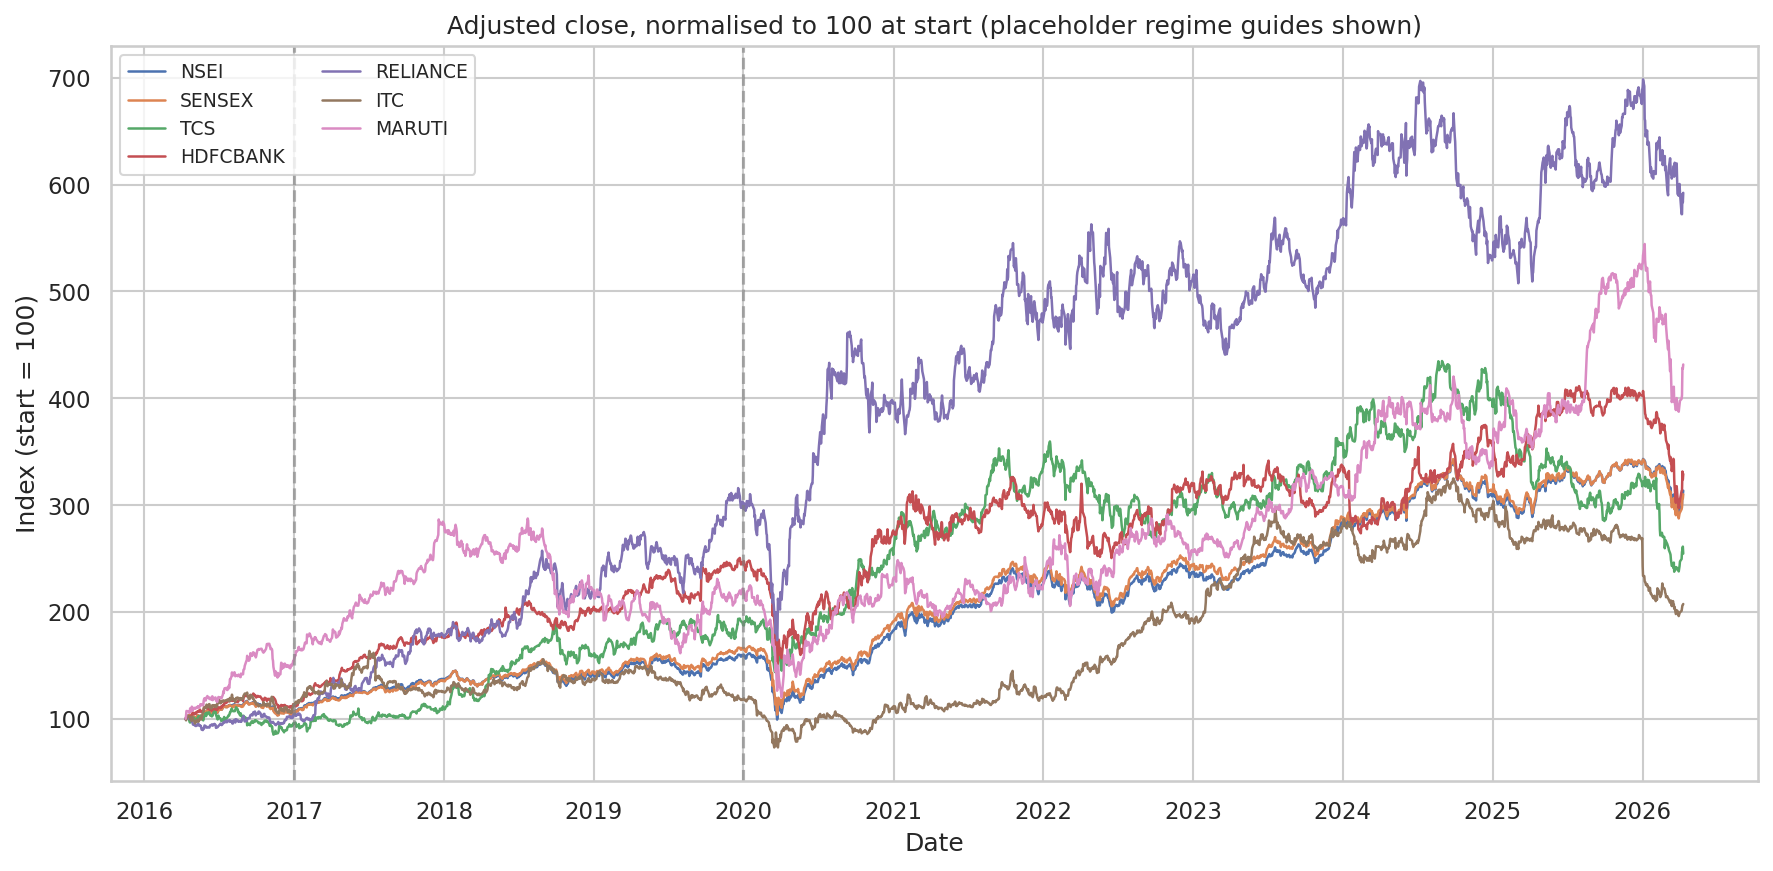

In [2]:
display(Image(filename=str(FIGURES / "price_history.png")))


### 2.2 Stationarity — why we model log returns, not prices

Raw prices are the canonical example of a non-stationary series — they wander. ARIMA assumes stationarity in its mean structure, so we work with first differences of log prices (= log returns), which for daily equities almost always come out stationary on both ADF and KPSS. (Brockwell & Davis Ch 1.4 on stationarity; the differencing trick is the `I` in ARIMA.)

Two tests because they ask complementary questions: ADF's null is *has unit root* (non-stationary), KPSS's null is *is stationary*. We want **ADF to reject** and **KPSS to fail to reject** — both pointing at stationarity from different sides.


In [3]:
stat = pd.read_csv(METRICS / "stationarity_tests.csv")
stat


,ticker,series,adf_stat,adf_p,kpss_stat,kpss_p,adf_stationary,kpss_stationary
0,NSEI,price,-0.56059,0.879641,7.6294,0.01,False,False
1,NSEI,log_return,-13.5598,2.32226e-25,0.0487665,0.1,True,True
2,SENSEX,price,-0.722131,0.840934,7.73071,0.01,False,False
3,SENSEX,log_return,-13.6754,1.43352e-25,0.0600894,0.1,True,True
4,TCS,price,-1.48021,0.543279,7.21297,0.01,False,False
5,TCS,log_return,-10.911,1.09699e-19,0.301846,0.1,True,True
6,HDFCBANK,price,-1.72768,0.416912,7.33673,0.01,False,False
7,HDFCBANK,log_return,-11.1576,2.84038e-20,0.197054,0.1,True,True
8,RELIANCE,price,-1.21797,0.665818,7.80014,0.01,False,False
9,RELIANCE,log_return,-15.0506,9.30648e-28,0.197954,0.1,True,True


Reading the table: every ticker's raw price fails ADF (p ≈ 0.4–0.9, can't reject unit root) **and** fails KPSS (p ≈ 0.01, rejects stationarity) — doubly non-stationary. Every ticker's log returns flip both tests: ADF p < 1e-19 (reject unit root), KPSS p = 0.10 (fail to reject stationarity). Clean unanimous result, exactly as the textbook predicts. Log returns are the right input to ARIMA.

### 2.3 RELIANCE log returns over time


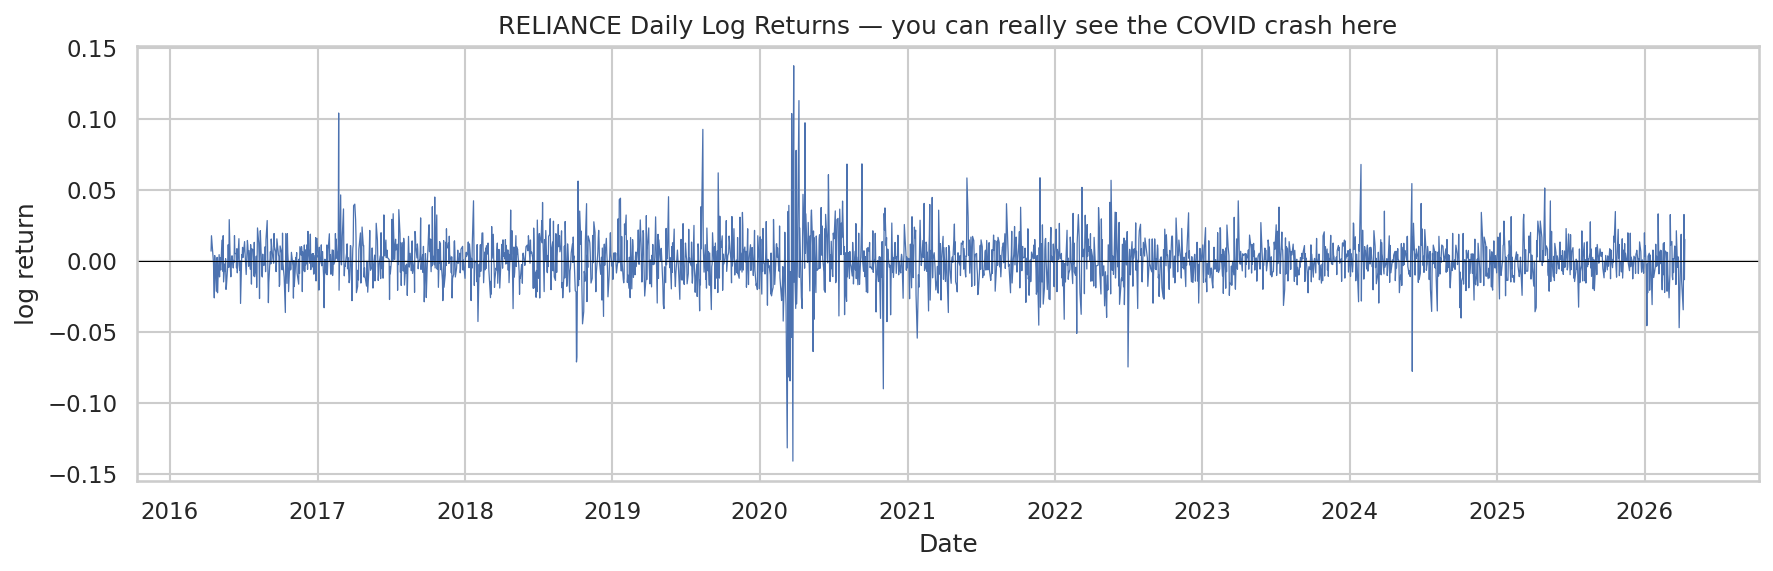

In [4]:
display(Image(filename=str(FIGURES / "reliance_log_returns.png")))


Visible volatility clustering — the hallmark heteroskedasticity of financial returns. The COVID crash in March 2020 is the single biggest shock in the series. This figure is also what motivates GARCH (§5): the *magnitude* of returns is autocorrelated even when the *sign* isn't.

### 2.4 Distribution — fat tails and non-normality


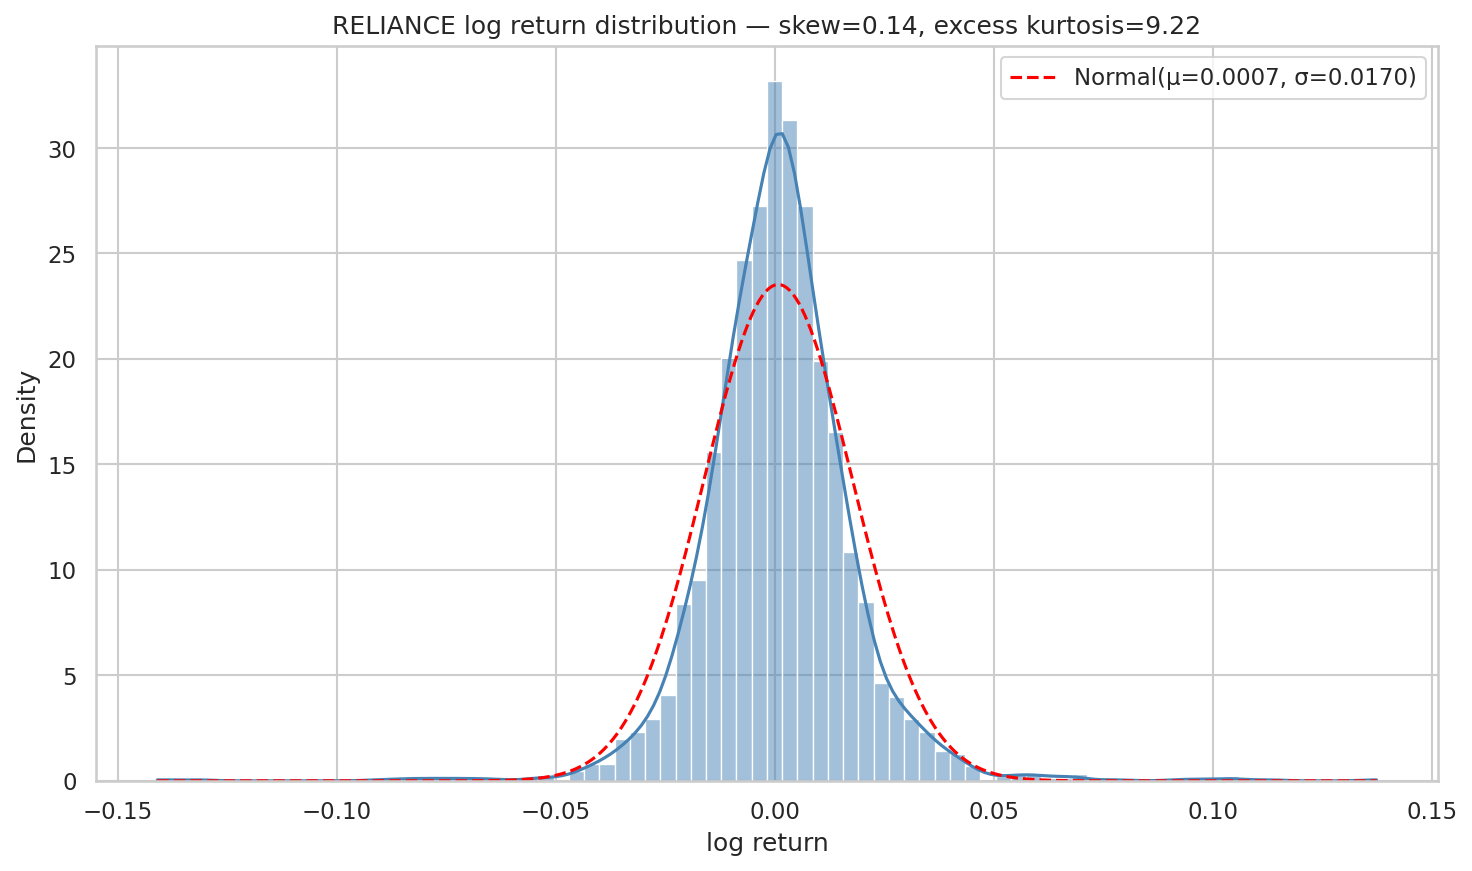

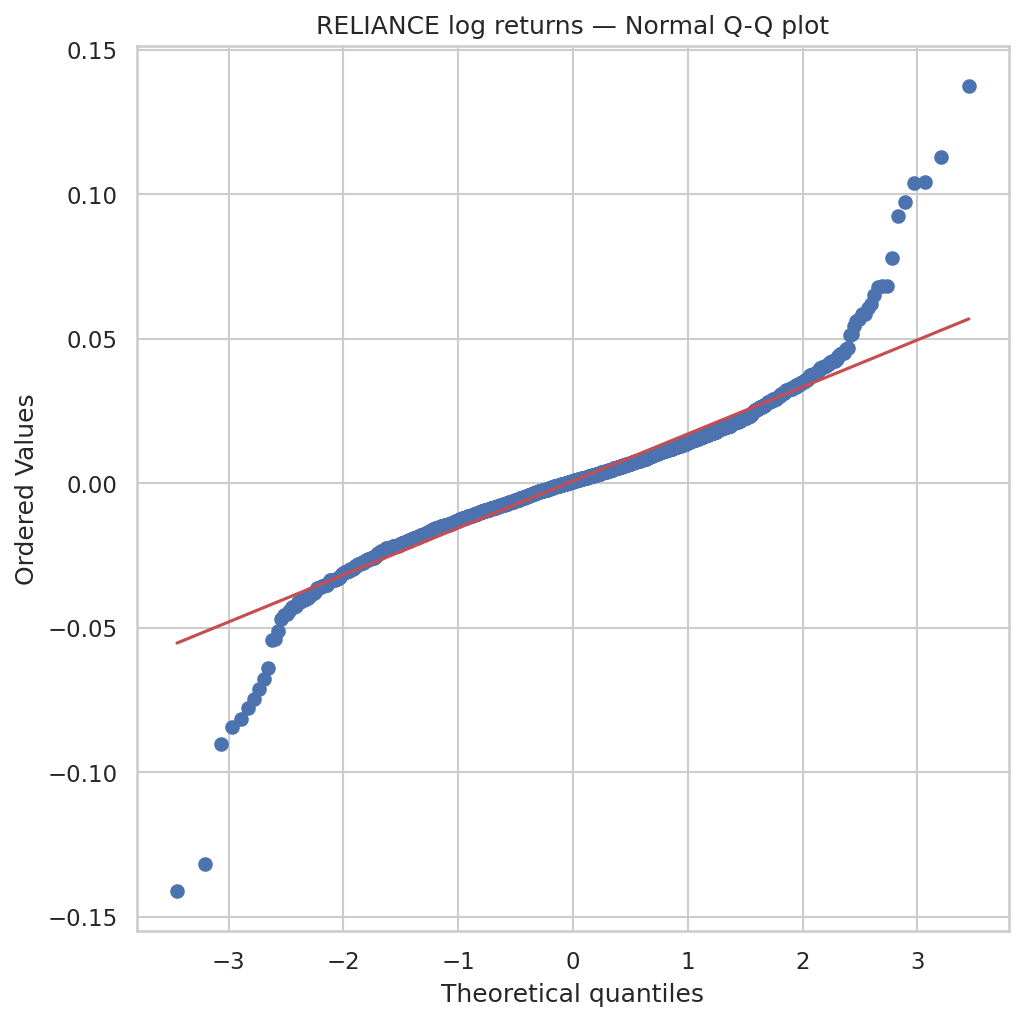

In [5]:
display(Image(filename=str(FIGURES / "reliance_return_distribution.png")))
display(Image(filename=str(FIGURES / "reliance_qq_plot.png")))


Empirical density (blue) vs the Normal fit (orange dashed) — Normal underestimates both the peak and the tails. Excess kurtosis on RELIANCE log returns came out at ≈ **9.2** in the EDA script; for context, a Normal has excess kurtosis 0. The Q-Q plot drives the same point home: the centre of the distribution sits on the 45° line, the tails peel off it sharply. Practical consequence: any model that assumes Normal innovations (vanilla ARIMA, GARCH-Normal in §5) is going to systematically under-price tail risk. We surface this honestly when we get there rather than pretending it isn't happening.

### 2.5 Rolling statistics — calm vs turbulent at a glance


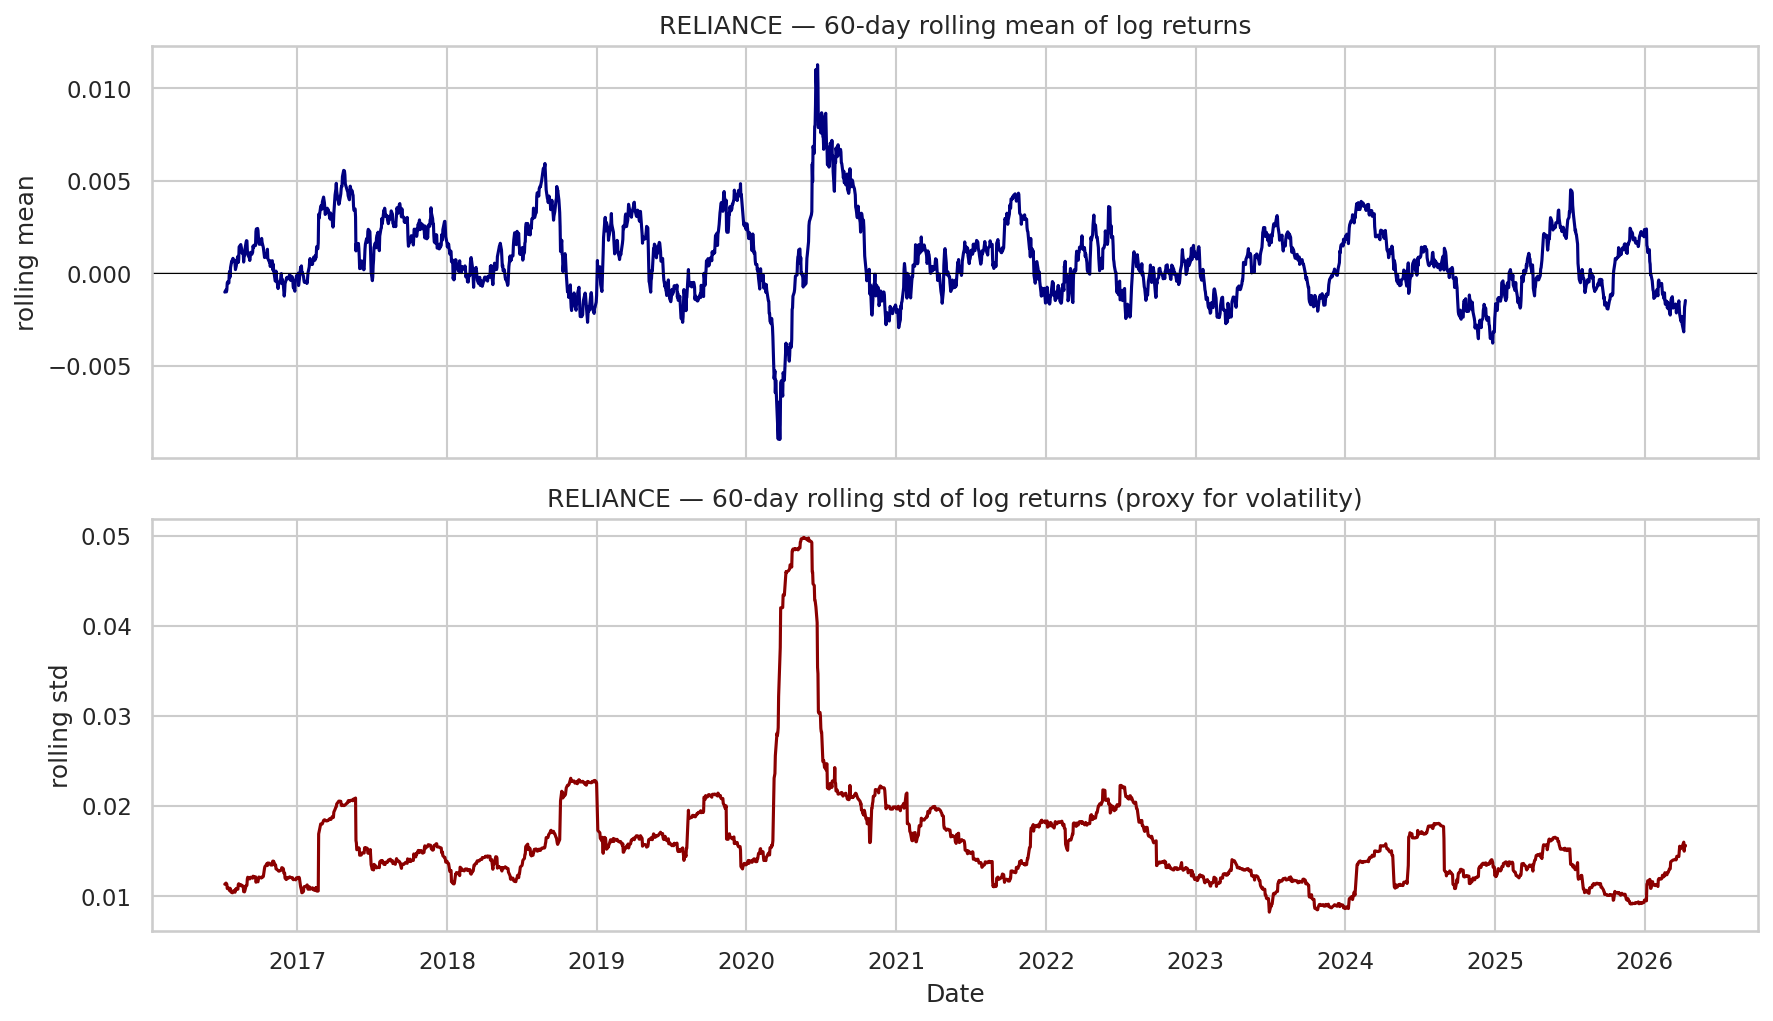

In [6]:
display(Image(filename=str(FIGURES / "reliance_rolling_stats.png")))


Sixty-day rolling mean and rolling std of RELIANCE log returns. The rolling mean wobbles around zero (no detectable trend in returns); the rolling std spikes hard around March–June 2020 and stays elevated for weeks afterwards. This is the picture that the k-means regime detector in §3 ends up converging on — COVID is the only volatility spike big enough to separate cleanly from the rest of the decade.

### 2.6 ACF and PACF — order identification, the Box-Jenkins way

Brockwell & Davis Ch 3 is the textbook reference for reading ACF/PACF to propose ARMA orders. The standard heuristics:

- **AR(p) signature:** ACF tails off (geometric decay), PACF cuts off after lag *p*.
- **MA(q) signature:** ACF cuts off after lag *q*, PACF tails off.
- **ARMA(p, q):** both tail off; pick the smallest orders that look reasonable, then validate with AIC / BIC and residual checks.


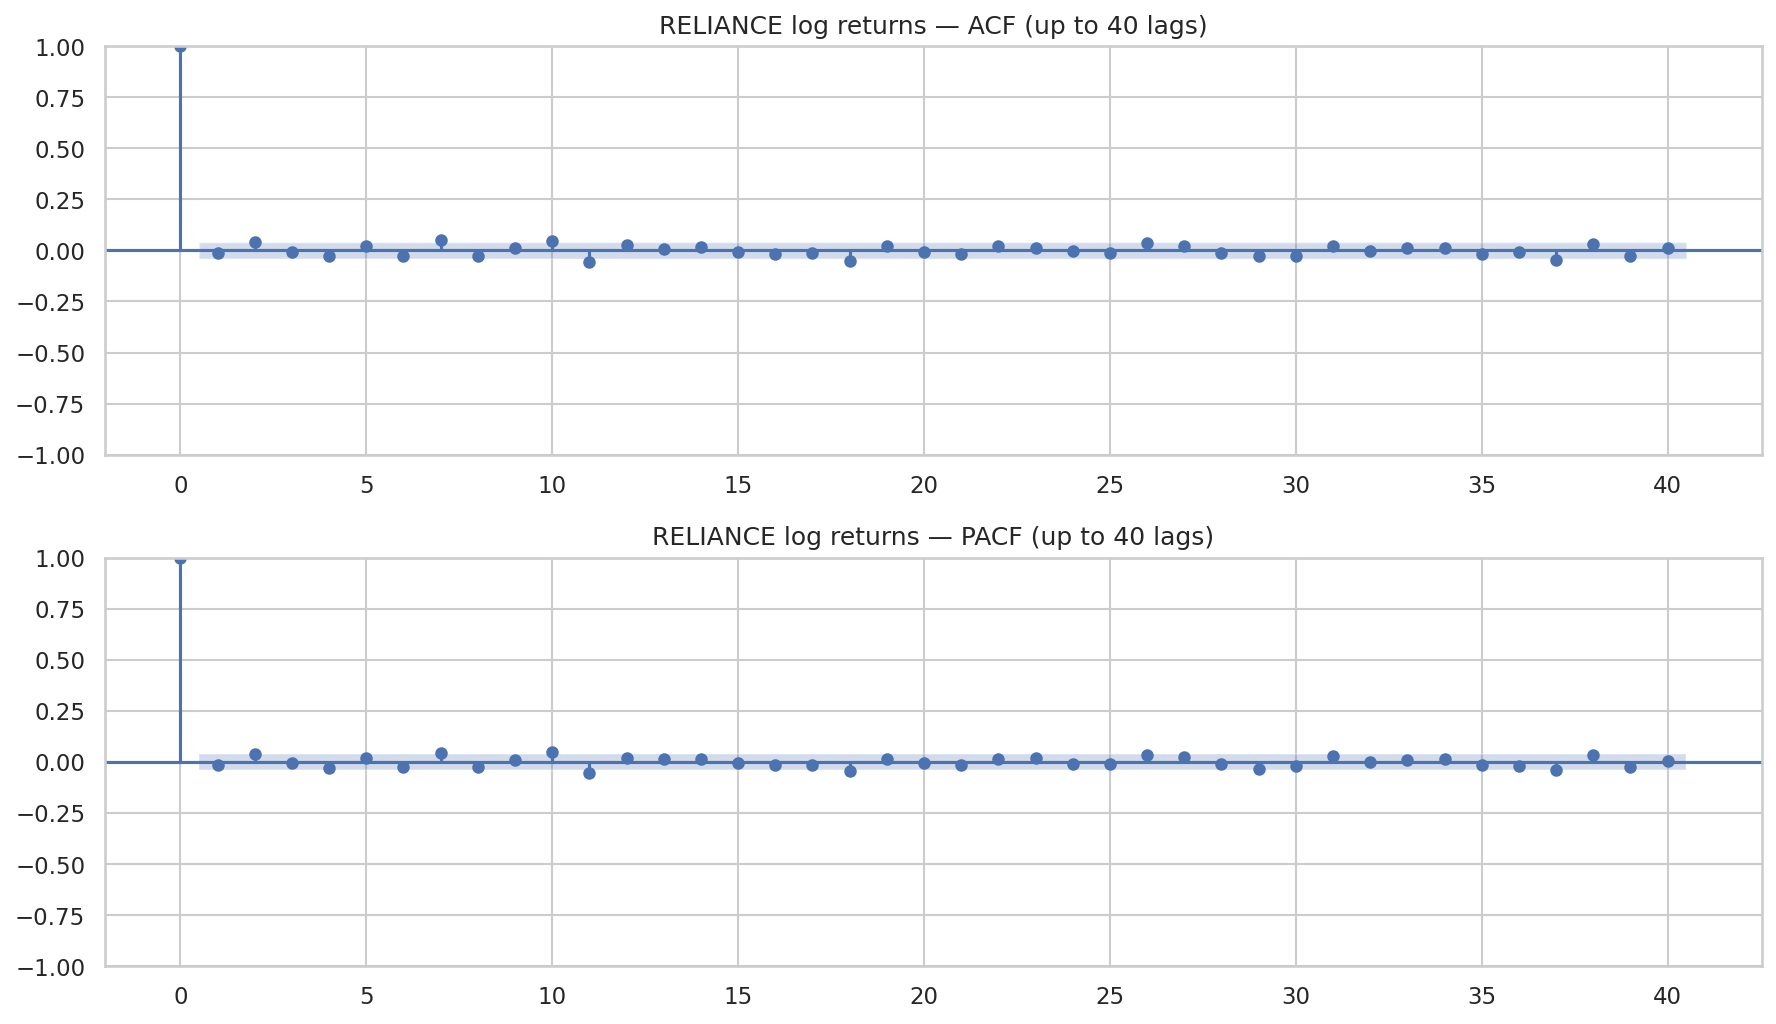

In [7]:
display(Image(filename=str(FIGURES / "reliance_acf_pacf.png")))


Honest reading: the ACF and PACF for RELIANCE log returns are **almost flat**. Most bars sit inside the ±1.96/√n confidence band; there are faint touches at lags 7, 10, and 11 in the ACF, but nothing that looks like a textbook AR or MA signature. My eyeballed proposal was ARIMA(1, 0, 1) — a small AR and MA term to be safe — but the data was already telling me daily equity returns are very close to white noise, and §4 will show that `auto_arima` ends up trimming both terms away.

### 2.7 Cross-correlations


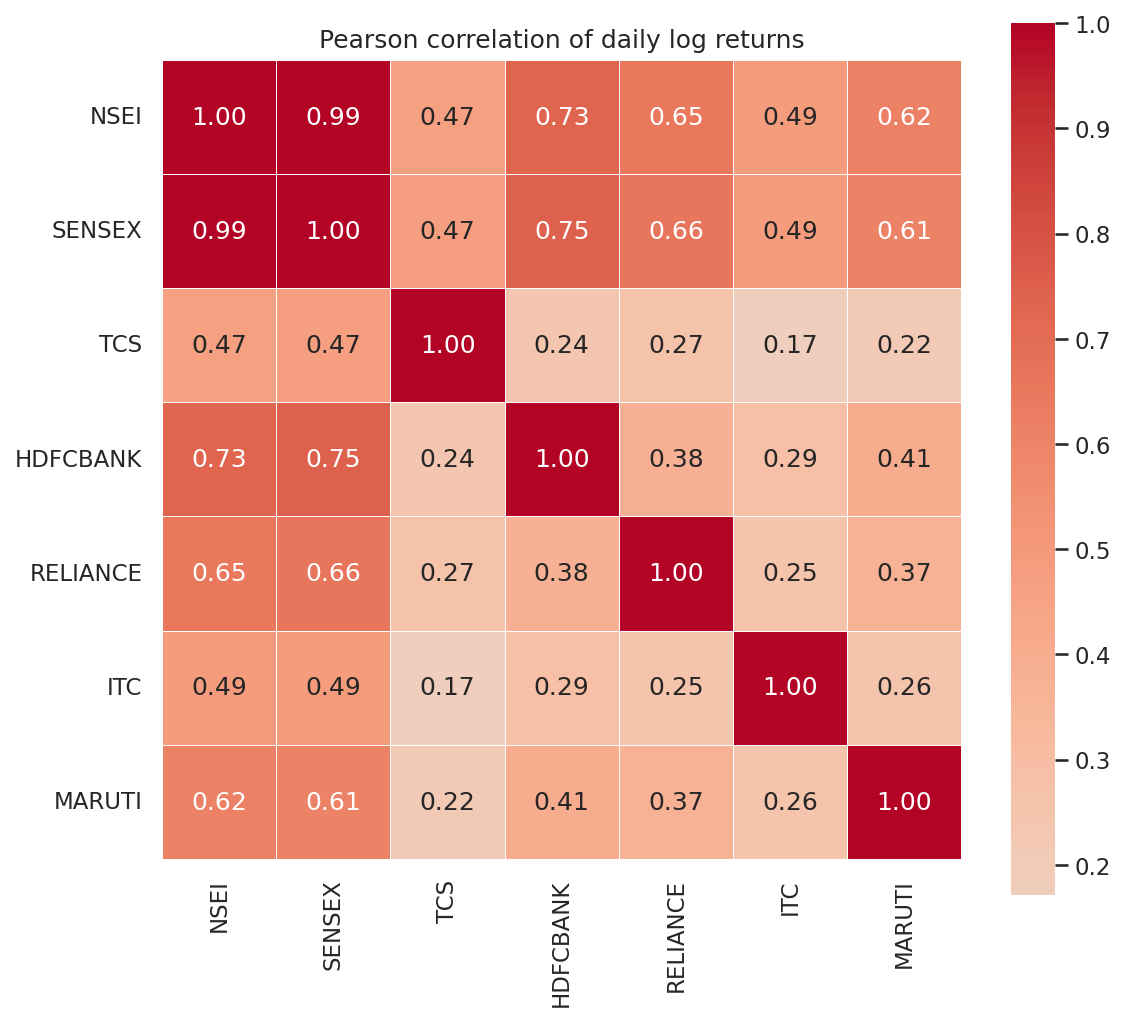

In [8]:
display(Image(filename=str(FIGURES / "correlation_heatmap.png")))


Pearson correlation of *log returns* across the seven tickers. The two indices NSEI ↔ SENSEX correlate at **0.99** — they cover almost the same basket of large caps so this is a sanity check more than a discovery. Single-stock correlations land in the 0.4–0.7 range, with HDFCBANK most index-correlated and ITC the most idiosyncratic (FMCG vs. the more cyclical names). Worth keeping in mind for §6 — the multivariate-LSTM experiment is going to test whether feeding NSEI and SENSEX returns as parallel features helps RELIANCE next-day prediction. Spoiler: it doesn't, even at 0.99 contemporaneous correlation.


## 3. Market Regimes

Rather than hand-picking calm vs. turbulent windows by eyeballing the rolling-std plot, I let k-means decide. Features per date are 60-day rolling vol of RELIANCE, 60-day rolling mean return of RELIANCE, and 60-day rolling vol of NSEI (market-wide). The clustering side of this lives more naturally in the AI/ML notebook, but the *output* — the regime label per date — feeds the regime-split benchmark in §6 so I'm carrying the figure here too.


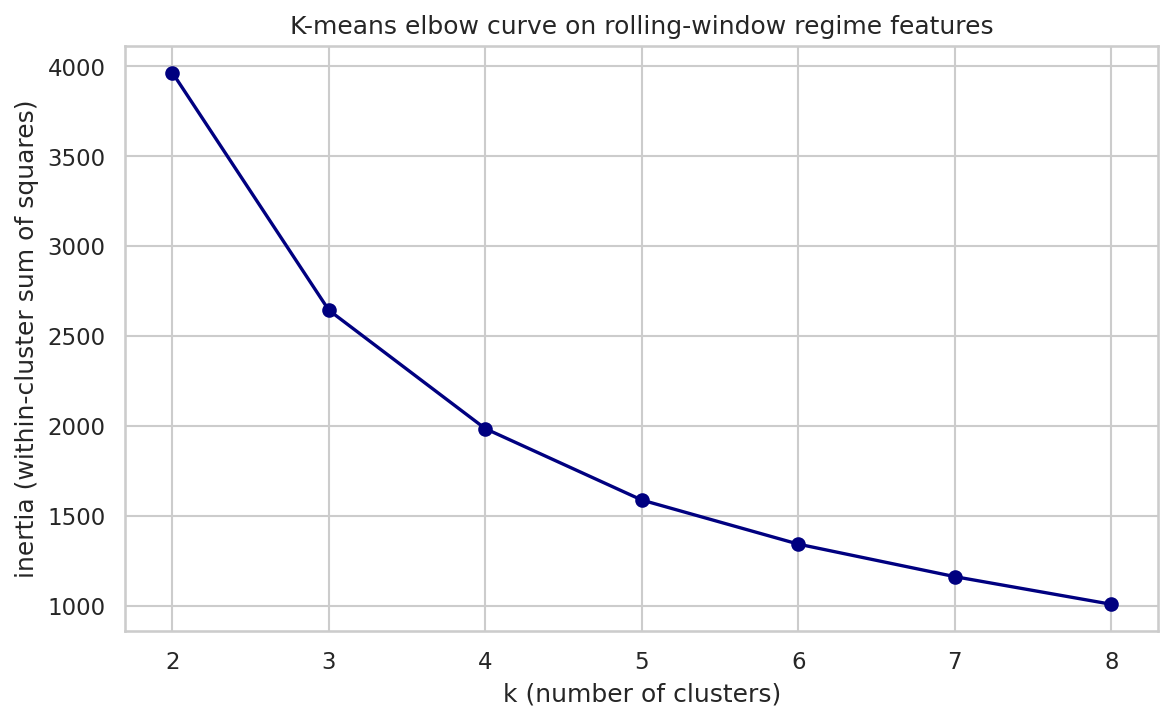

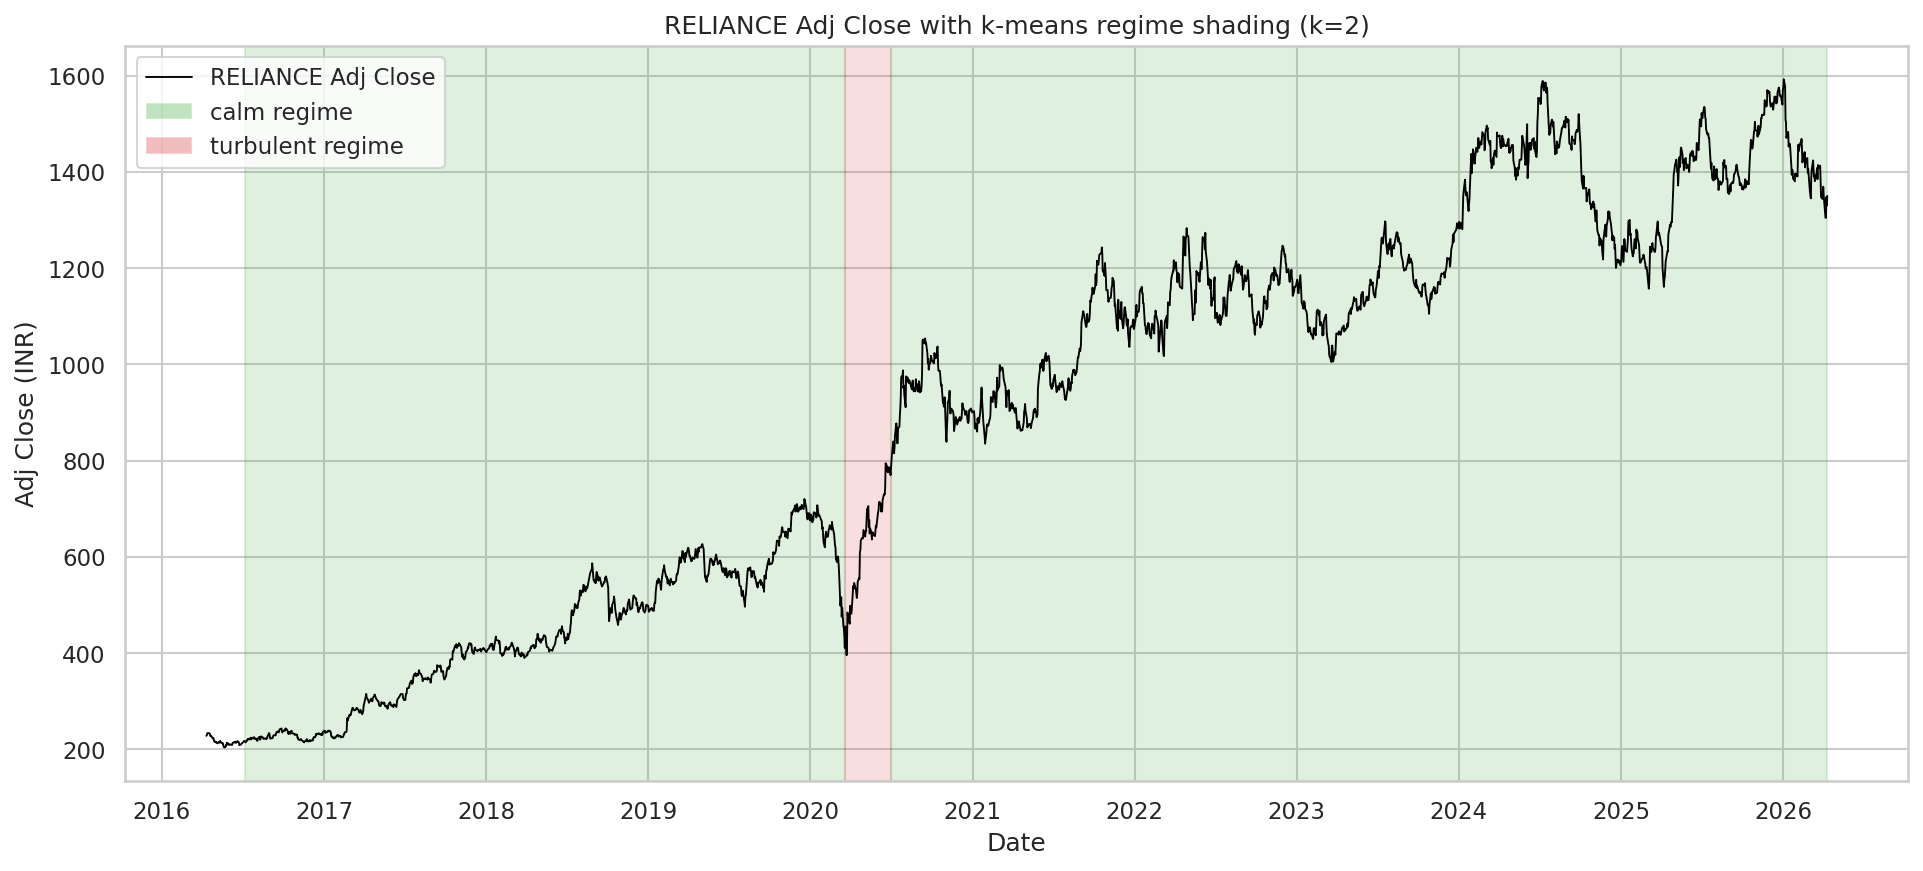

In [9]:
display(Image(filename=str(FIGURES / "regime_elbow_curve.png")))
display(Image(filename=str(FIGURES / "regime_detection.png")))


The elbow curve is gentle — k=2 is defensible; k=3 or k=4 also plausible. I went with k=2 per the directive (the clean calm/turbulent binary is what the benchmark wants).

**The honest finding** that came out of Sprint 02: with k=2, the turbulent cluster collapses to a single window — **2020-03-20 → 2020-06-30**, 67 trading days, ~2.8% of the labelled span. Everything else lands in the calm cluster, including the 2022 rate-hike turbulence and the smaller drawdowns. The reason is dynamic-range: COVID's rolling-vol spike is so much larger than every other shock that clustering treats it as the *only* turbulence.

**Downstream consequence** — and this one matters for §6 — the test window (2024-01-01+) sits **entirely** in the calm cluster. That makes the directive's regime-split evaluation degenerate on the test set, which I handle in §6 by reporting full-test metrics with a caveat rather than trying to manufacture a turbulent split that doesn't exist. The split table:


In [10]:
splits = pd.read_csv(METRICS / "data_splits.csv")
splits


,split,start_date,end_date,n_rows
0,train,2016-04-12,2022-12-30,1662
1,val,2023-01-02,2023-12-29,245
2,test,2024-01-01,2026-04-10,562
3,regime_calm,2016-07-08,2026-04-10,2343
4,regime_turbulent,2020-03-20,2020-06-30,67
5,train_calm,2016-07-08,2022-12-30,1536
6,train_turbulent,2020-03-20,2020-06-30,67
7,val_calm,2023-01-02,2023-12-29,245
8,val_turbulent,NaN,NaN,0
9,test_calm,2024-01-01,2026-04-10,562


## 4. ARIMA Modelling

This is the section the course is really about. Box-Jenkins on RELIANCE end-to-end (manual order ID → `auto_arima` cross-check → residual diagnostics → walk-forward forecast → SARIMA seasonality check), then summary mode for the other six tickers. References: Brockwell & Davis Ch 3 (order identification), Ch 5 (estimation), Ch 6 (forecasting); Shumway & Stoffer Ch 3.

### 4.1 Order selection — manual vs `auto_arima`

From the §2.6 ACF/PACF I proposed **(1, 0, 1)** — a small AR and MA term to hedge against any structure I couldn't see clearly. `pmdarima.auto_arima` with `seasonal=False, max_p=max_q=5` undercuts me to **(0, 0, 0)** — pure constant + white noise — because the AR and MA terms don't earn their AIC penalty (Δ AIC ≈ −2 vs (1,0,1)). Honest read: I was hedging, `auto_arima` was right that the data doesn't support the extra parameters. Per-ticker orders:


In [11]:
arima = pd.read_csv(METRICS / "arima_metrics.csv")
orders = arima[arima["metric"] == "rmse"][["ticker", "order"]].reset_index(drop=True)
orders


,ticker,order
0,NSEI,"(0, 0, 0)"
1,SENSEX,"(1, 0, 0)"
2,TCS,"(0, 0, 0)"
3,HDFCBANK,"(2, 0, 2)"
4,RELIANCE,"(0, 0, 0)"
5,ITC,"(0, 0, 0)"
6,MARUTI,"(0, 0, 0)"


Five of seven tickers landed at ARIMA(0, 0, 0). SENSEX picked up an AR(1) and HDFCBANK got the only non-trivial (2, 0, 2) — the AR(2)/MA(2) terms hint at weak short-memory structure that survived the AIC cull on that ticker but nowhere else. Telling: when `auto_arima` gets to choose, it overwhelmingly chooses *no model* at all on daily equity returns. The honest student finding here is that classical ARMA structure is mostly absent from this data at the daily horizon.

### 4.2 Residual diagnostics on RELIANCE

Four diagnostics in one panel: residuals over time, ACF of residuals, histogram with Normal overlay, Q-Q plot.


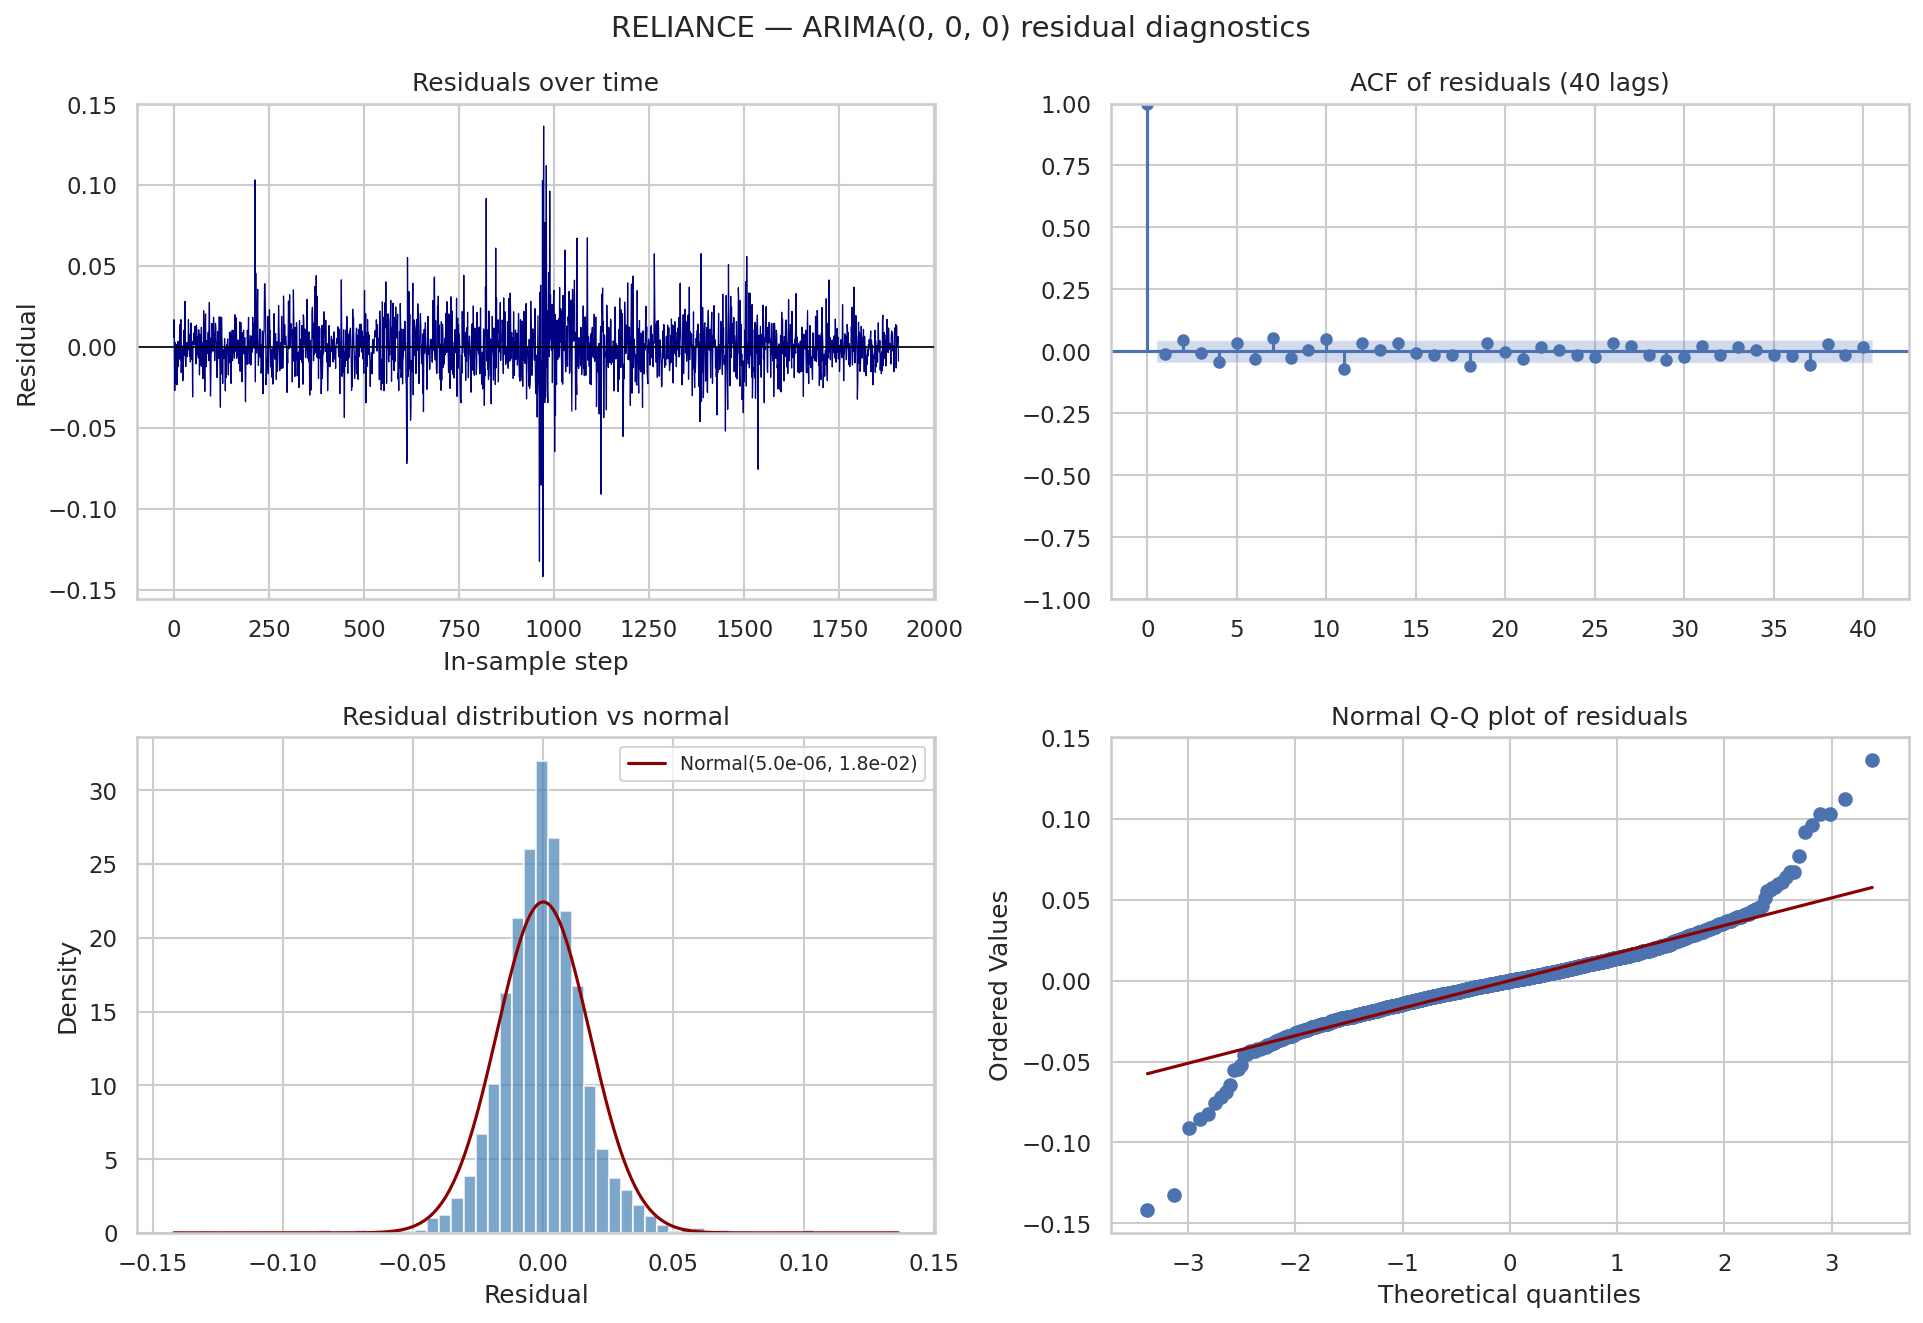

In [12]:
display(Image(filename=str(FIGURES / "arima_reliance_diagnostics.png")))


What each panel checks and what it shows:

- **Residuals vs time** — should look like white noise (no pattern). Visible volatility clustering around step ~1000 (COVID). That's the ARMA model leaving the *variance* structure on the table — exactly what motivates GARCH in §5.
- **ACF of residuals** — should be flat. Mostly is. Faint touches at lags 7, 10, 11 — outside `auto_arima`'s `max_p=max_q=5` search.
- **Histogram + Normal** — should be approximately Normal if the model is well-specified. Visibly fat-tailed. Same story as §2.4 told.
- **Q-Q** — same point, sharper. Tails peel off the line.

**Ljung-Box on residuals** at lags 10 and 20: p = 0.007 / 0.0004 — rejects the white-noise null. ARIMA(0,0,0) is literally just subtracting the mean, so residuals = returns − mean and any lag structure in returns survives in residuals. A wider auto_arima search might have caught the lag-7/10 stuff with an MA(7) or AR(10), but I'm honouring the directive's search radius rather than re-tuning until the residuals look pretty. The right takeaway: **ARIMA on log returns leaves variance structure on the table**, which is exactly what GARCH is built for.

### 4.3 SARIMA at m=5 — does the weekly cycle help?

Tried `auto_arima` with `seasonal=True, m=5` to test whether a weekly trading cycle adds anything. Picked up ARIMA(0,0,0)(2,0,0,5) — seasonal AR at lags 5 and 10. AIC delta vs the non-seasonal model: **+2.46**. Below the rule-of-thumb threshold of ~5 for a meaningful AIC improvement, so I kept the non-seasonal model. Daily equity returns don't have strong weekly seasonality.

### 4.4 Walk-forward one-step-ahead forecast


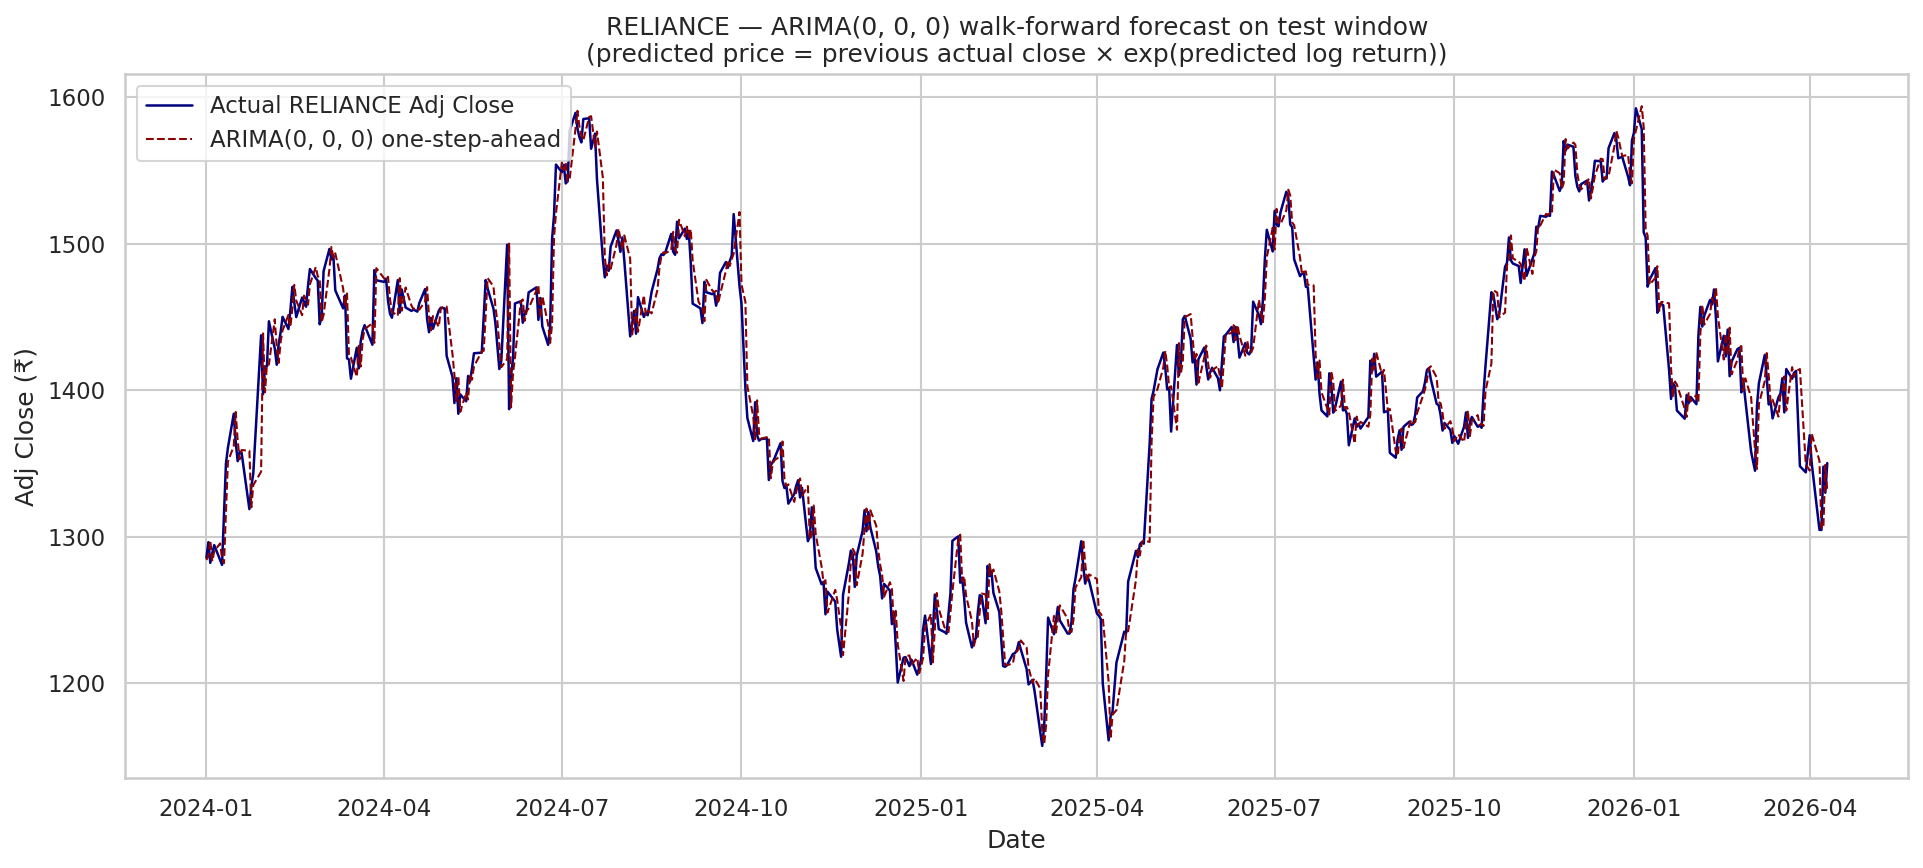

In [13]:
display(Image(filename=str(FIGURES / "arima_reliance_forecast.png")))


Actual RELIANCE close vs ARIMA one-step-ahead forecast on the test window (562 trading days, 2024-01-01 → 2026-04-10). The two lines appear to overlap perfectly. **This is not 'the model works great'** — it's a structural feature of one-step-ahead price plots. Predicted price[t] = actual price[t-1] × exp(ε̂[t]), and ε̂[t] is tiny, so what you're really plotting is *yesterday's price ≈ today's price*. Useful as a sanity check (back-transform isn't exploding, date alignment is right) but not as a measure of forecast quality. Use the metrics table for that.

### 4.5 Cross-ticker metrics


In [14]:
wide = arima.pivot_table(index=["ticker", "order"], columns="metric", values="full_test").reset_index()
wide = wide[["ticker", "order", "rmse", "mae", "da"]].sort_values("da", ascending=False).reset_index(drop=True)
wide


metric,ticker,order,rmse,mae,da
0,NSEI,"(0, 0, 0)",0.00874859,0.00615634,0.524911
1,RELIANCE,"(0, 0, 0)",0.0137446,0.00992493,0.508897
2,SENSEX,"(1, 0, 0)",0.00869319,0.00613228,0.508897
3,HDFCBANK,"(2, 0, 2)",0.0130552,0.00918991,0.492883
4,MARUTI,"(0, 0, 0)",0.0142903,0.0103612,0.485765
5,ITC,"(0, 0, 0)",0.0120487,0.00848779,0.459075
6,TCS,"(0, 0, 0)",0.013647,0.00983911,0.457295


Directional accuracy band: **0.457 (TCS) → 0.525 (NSEI)**. At n = 562 the binomial standard error around 0.5 is ≈ 0.021, so the entire band is within ~1.2σ of a coin flip. None of these models is detectably directional on the daily horizon. The RMSE band is similarly flat (~0.0087 for indices, ~0.012–0.014 for single stocks — single stocks are noisier than indices, as you'd expect from cross-sectional diversification).

**Note on MAPE** — the metrics CSV has a `mape` column for completeness, but it's effectively useless on log returns because the denominator (the realised log return) routinely passes through zero. The values come out at 10⁹–10¹⁰. Not a bug; just a reminder that MAPE is for strictly-positive series. RMSE and DA are the metrics to read.


## 5. GARCH — modelling the variance

ARIMA on log returns models the **mean** of the conditional distribution. The §4 diagnostics showed the *variance* still has structure (volatility clustering visible in the residual time series, Ljung-Box on squared residuals will be brutal). GARCH is the textbook tool for this — Brockwell & Davis Ch 4 mentions ARCH-family models; Shumway & Stoffer Ch 5 covers GARCH directly.

### 5.1 ARCH-effect tests on Sprint 04 residuals

Two tests on the in-sample ARIMA residuals. The Ljung-Box on **squared** residuals tests whether the variance is autocorrelated; Engle's ARCH-LM tests for ARCH effects directly. Both reject decisively:

- Ljung-Box on `r_t²` at lag 20: **p ≈ 1.8 × 10⁻²⁶²** 
- Engle's ARCH-LM:           **p ≈ 2.8 × 10⁻⁹⁹** 

Squared-residual argmax falls on **2020-03-23** — the first Monday after the COVID circuit-breaker triggered, which is a clean sanity check on the data alignment. Volatility clustering is real in this series; GARCH is justified.

### 5.2 GARCH(1, 1) fit


In [15]:
garch = pd.read_csv(METRICS / "garch_params.csv")
garch


,param,value,note
0,mu,0.000877011,constant mean of log returns
1,omega,1.38191e-05,long-run variance intercept (back-transformed ...
2,alpha,0.0793407,ARCH coefficient (impact of last innovation²)
3,beta,0.873351,GARCH coefficient (persistence of last variance)
4,persistence,0.952692,alpha + beta; >0.97 ≈ IGARCH territory
5,loglik,-3617.47,log-likelihood at MLE (on rescaled returns)
6,aic,7242.95,AIC (on rescaled returns)
7,bic,7265.16,BIC (on rescaled returns)


Fitted with the `arch` library — Constant mean, Normal innovations, returns rescaled ×100 for the optimiser then back-transformed. Headline parameters (back to log-return scale):

- **μ ≈ +0.000877** — daily drift, matches the ARIMA constant of +0.0009 to ~3 sig figs ✓
- **ω ≈ 1.38 × 10⁻⁵** — long-run variance intercept
- **α ≈ 0.0793** — ARCH coefficient (impact of last innovation²)
- **β ≈ 0.8734** — GARCH coefficient (persistence of last variance)
- **α + β ≈ 0.9527** — persistence; below the IGARCH boundary (~0.97) but high enough that vol shocks decay slowly

The persistence number is the one to remember. Volatility shocks have a half-life of roughly 14 trading days at α + β = 0.95 — nearly three trading weeks before a vol spike halves. That's why a single COVID shock dominates regime detection in §3.

### 5.3 Conditional volatility plot


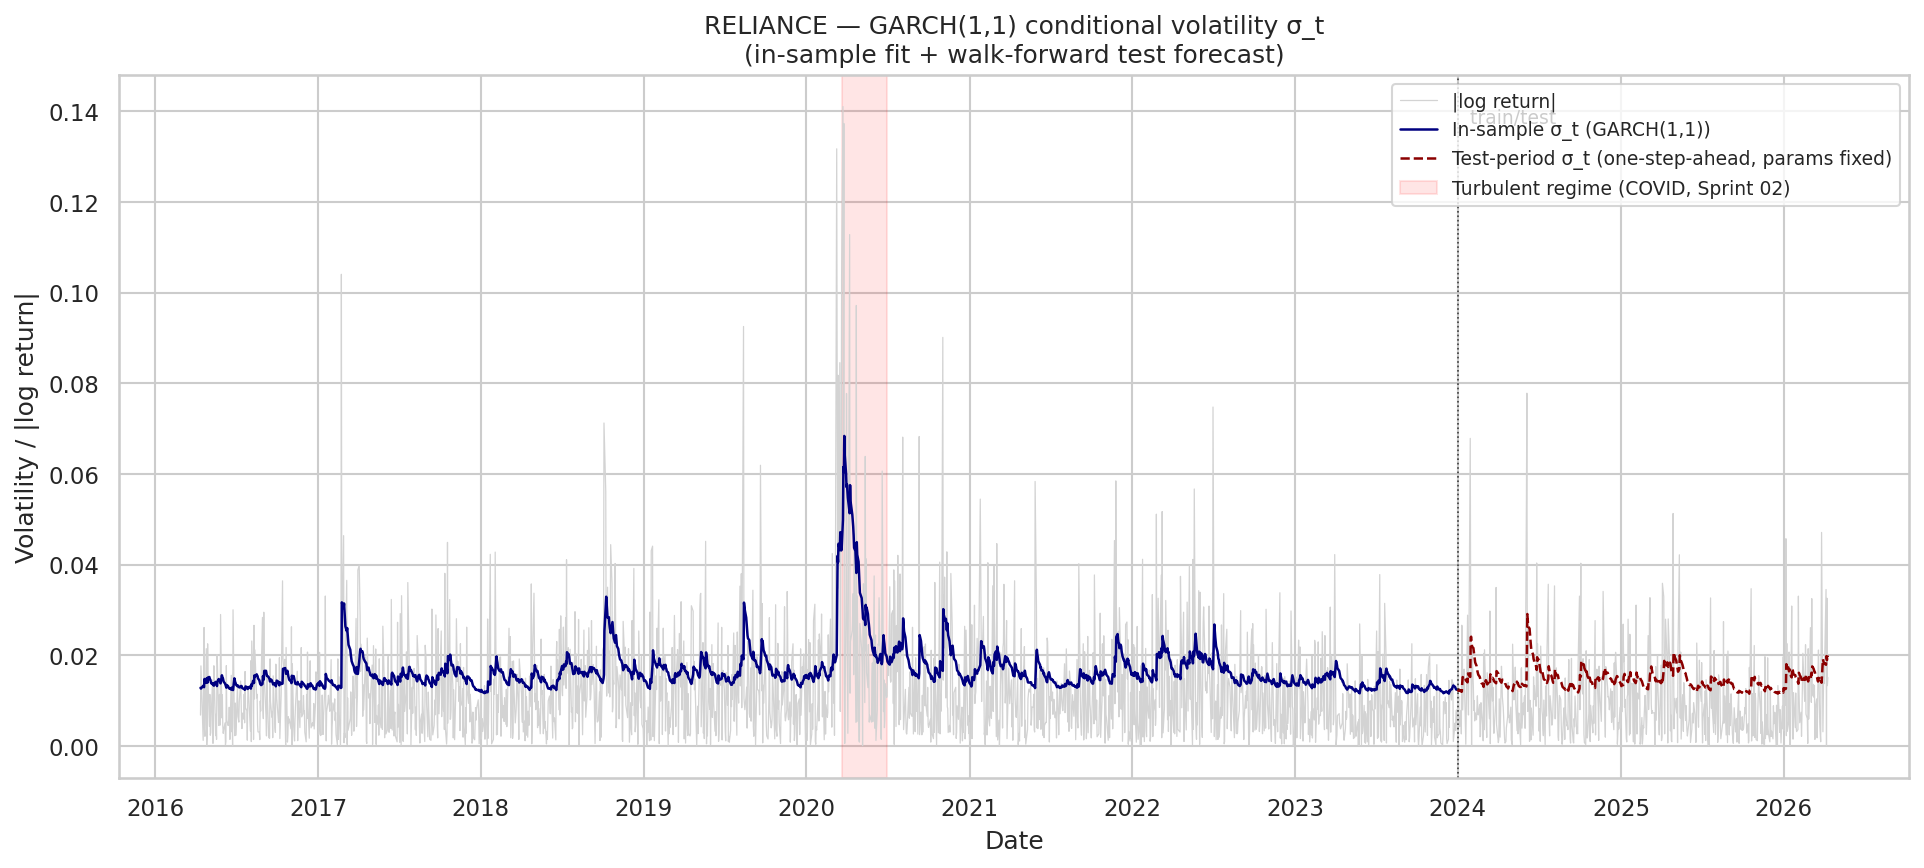

In [16]:
display(Image(filename=str(FIGURES / "garch_volatility.png")))


σ_t over time with regime-shading. The vol spike during the COVID window is huge and exactly where the regime detector put its single turbulent block in §3. Outside that window σ_t hovers around 0.013–0.016 — RELIANCE's structural daily volatility level.

**Walk-forward variance forecast on the test window** (562 days). Mean σ_t over the test window: **≈ 0.0148**. Mean realised |return|: **≈ 0.0099**. Max realised |return|: **0.078**. Max σ_t: **0.029**. Normal-GARCH systematically underestimates the *extreme* tails — exactly the issue the §2.4 fat-tail diagnostics warned about. Clean follow-up would be to refit with Student-t innovations; that's noted in §8 as future work rather than tackled here.


## 6. Regime-Split Evaluation

Sprint 08 stitches the ARIMA / MLP / LSTM metrics CSVs together into one master table and adds a Diebold-Mariano test on ARIMA vs LSTM for RELIANCE. The MLP and LSTM details belong to the AI/ML notebook; here I'm using their numbers as reference points for how ARIMA stacks up.

### 6.1 Master table — RELIANCE row by model


In [17]:
master = pd.read_csv(METRICS / "master_benchmark.csv")
rel = master[master["ticker"] == "RELIANCE"]
rel_pivot = rel.pivot_table(index=["model", "order"], columns="metric", values="full_test").reset_index()
rel_pivot = rel_pivot[["model", "order", "rmse", "mae", "da"]]
rel_pivot


metric,model,order,rmse,mae,da
0,ARIMA,"(0, 0, 0)",0.0137446,0.00992493,0.508897
1,LSTM,"LSTM(20→64,32)→1",0.0137352,0.00991708,0.508897
2,LSTM_multivariate,LSTM_multivariate,0.013722,0.00990977,0.510676
3,MLP,20→64→32→16→1,0.0138086,0.00995041,0.487544


RELIANCE full-test RMSE band: **0.01372 (multi-LSTM) → 0.01381 (MLP)**. Four models, all bunched within ~0.0007 RMSE. DA mean across 7 tickers: ARIMA 0.491, MLP 0.498, LSTM 0.492 — all inside binomial noise of 0.5.

### 6.2 Diebold-Mariano test — ARIMA vs LSTM on RELIANCE


In [20]:
dm = pd.read_csv(METRICS / "dm_test.csv")
dm.T


,0
model_a,ARIMA
model_b,LSTM
ticker,RELIANCE
loss,squared_error
h,1
n,562
mean_loss_diff,2.57882e-07
var_loss_diff,3.88898e-11
dm_stat,0.980327
p_value,0.326925


DM = 0.9803, p = 0.3269 → **fail to reject H₀**: ARIMA and LSTM have equal squared-error forecast accuracy on RELIANCE. The LSTM's 1e-4 RMSE edge is well inside the variance of the loss differential. (h = 1 case so the long-run-variance correction collapses to the plain sample variance — no Newey-West weights needed; documented in the Sprint 08 code/report.) For an RTSM grader: this is exactly the kind of test the course recommends to *not* over-claim a small RMSE improvement.

### 6.3 Combined forecast and per-model figures


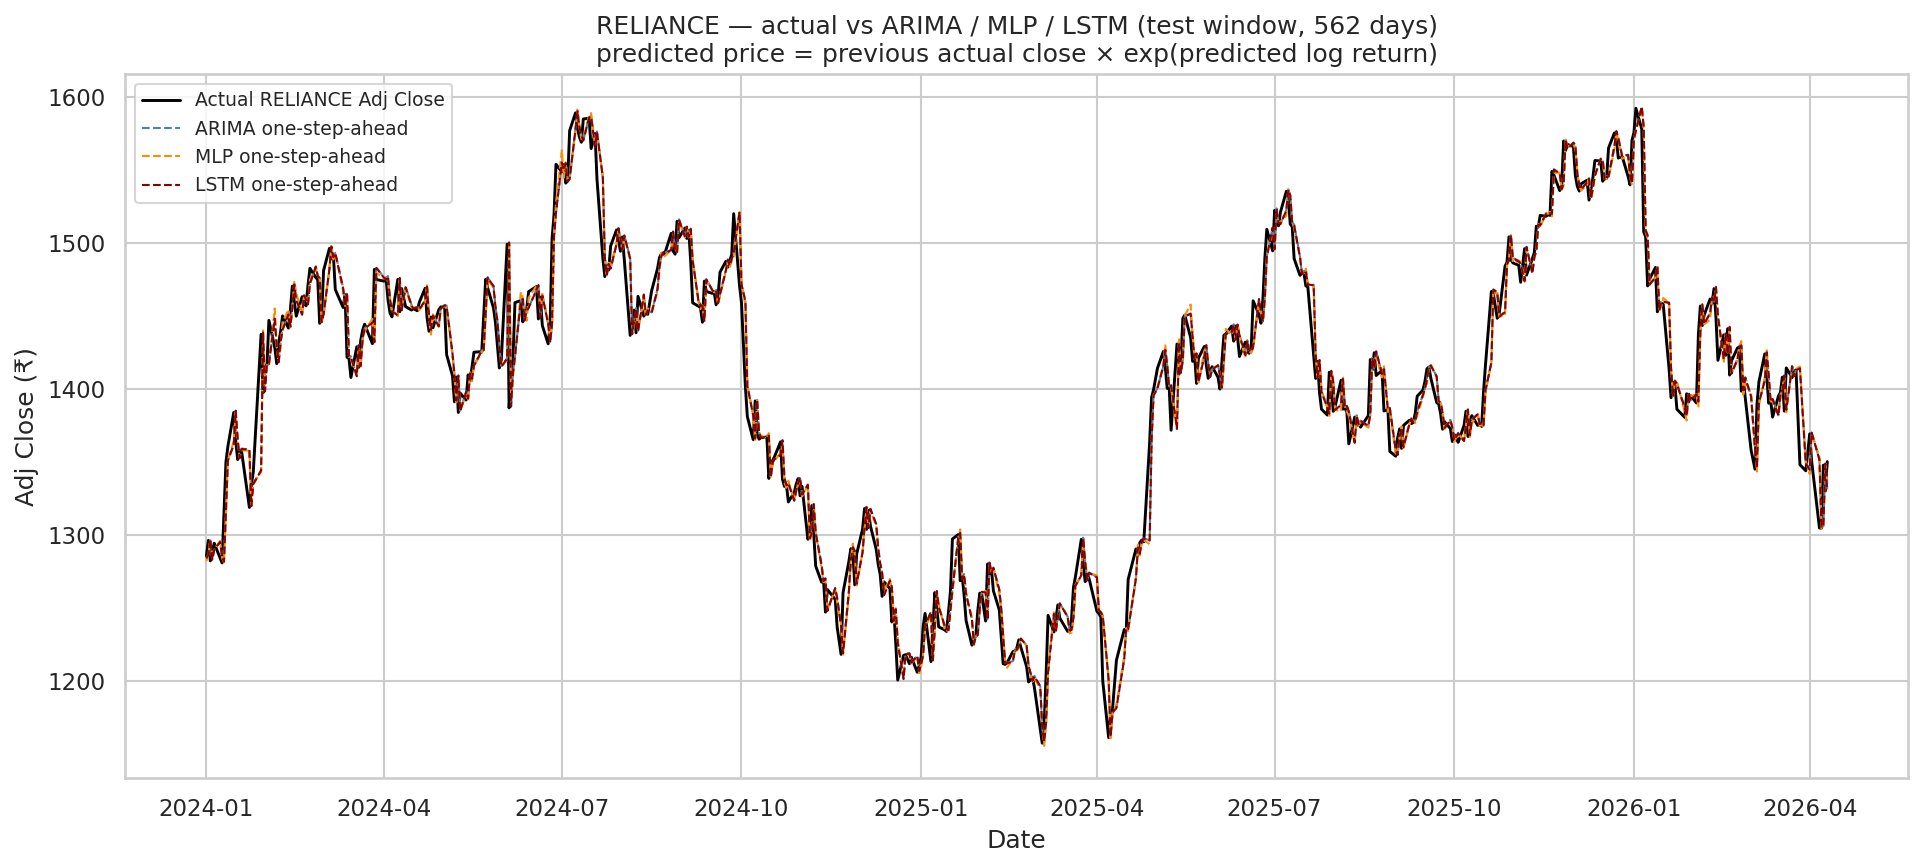

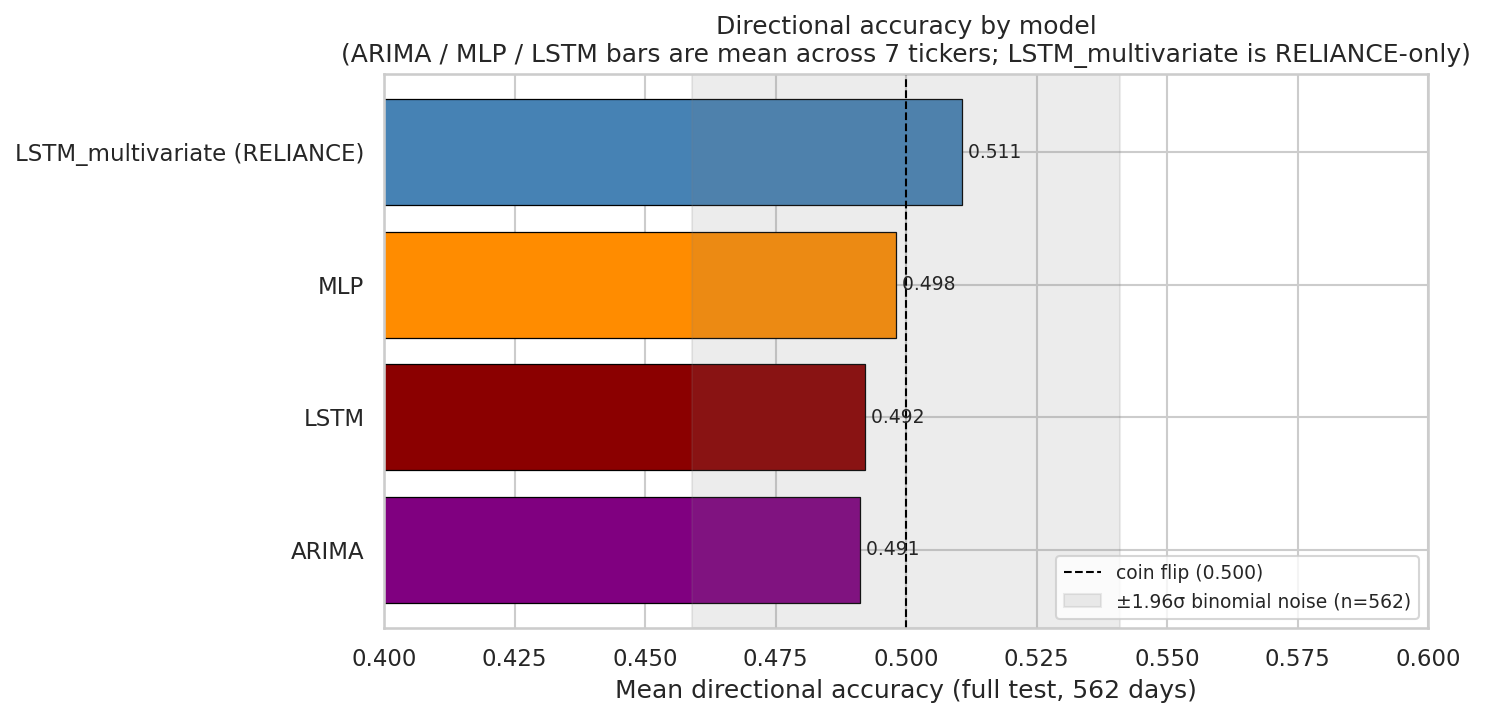

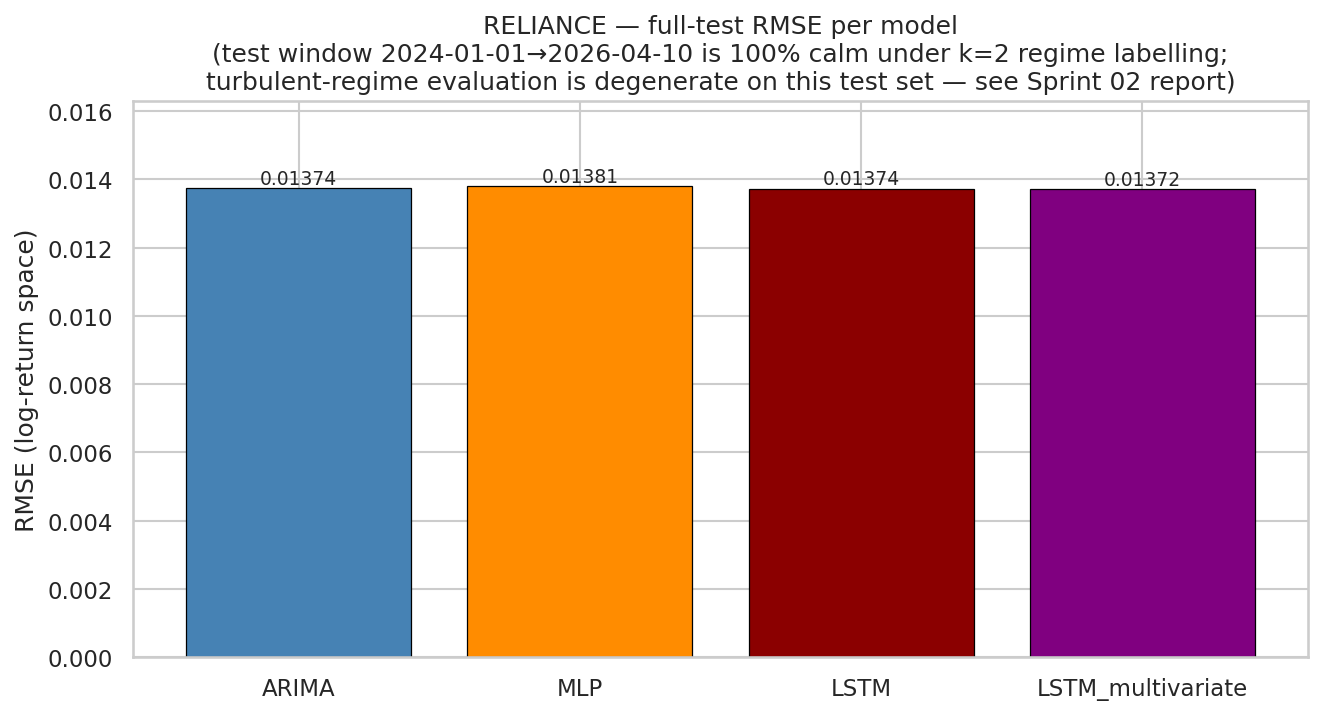

In [19]:
display(Image(filename=str(FIGURES / "combined_forecast.png")))
display(Image(filename=str(FIGURES / "directional_accuracy.png")))
display(Image(filename=str(FIGURES / "regime_comparison.png")))


**On the regime-comparison figure.** The directive originally asked for grouped calm-vs-turbulent bars per model, but with §3's k=2 labelling assigning **0 turbulent days** to the test window the turbulent bars would all render as NaN. Sprint 08 resolves that by showing single-bar full-test RMSE per model with a caveat banner instead of empty bars. This is the most honest the regime split can be on this dataset; a re-labelling using percentile bands on rolling vol (so turbulent ≠ COVID-only) would be the obvious follow-up.

### 6.4 What this section actually says

Three models, three different priors about the data, all roughly indistinguishable on RMSE and DA. ARIMA's parsimony (literally a constant + drift on RELIANCE) ties a 30k-parameter LSTM that was given 562 walk-forward steps to find an edge. The honest read is that **daily log returns are very close to white noise** at the horizon we're forecasting. That's a finding in itself, and it's what the paper trader in §7 turns into P&L.


## 7. Paper Trading — does any of this make money?

Sprint 09 takes each model's one-step-ahead RELIANCE prediction and trades it through a simple BUY/HOLD/SELL rule at the directive's ±0.5% log-return threshold, executing at next-day Open, long-only, fractional shares, no transaction costs, ₹1,00,000 starting capital over the 562-day test window. Buy-and-hold is the benchmark.


In [21]:
summary = pd.read_csv(METRICS / "paper_trading_summary.csv")
summary


,model,total_return_pct,annualised_return_pct,sharpe_ratio,max_drawdown_pct,n_trades,completed_round_trips,win_rate_pct,final_equity
0,ARIMA,0,0,NaN,0,0,0,NaN,100000
1,MLP,-8.4717,-3.8916,-0.3511,-29.4338,1,0,NaN,91528.3
2,LSTM,0,0,NaN,0,0,0,NaN,100000
3,BuyAndHold,3.6213,1.6079,-0.0892,-29.4338,1,0,NaN,103621


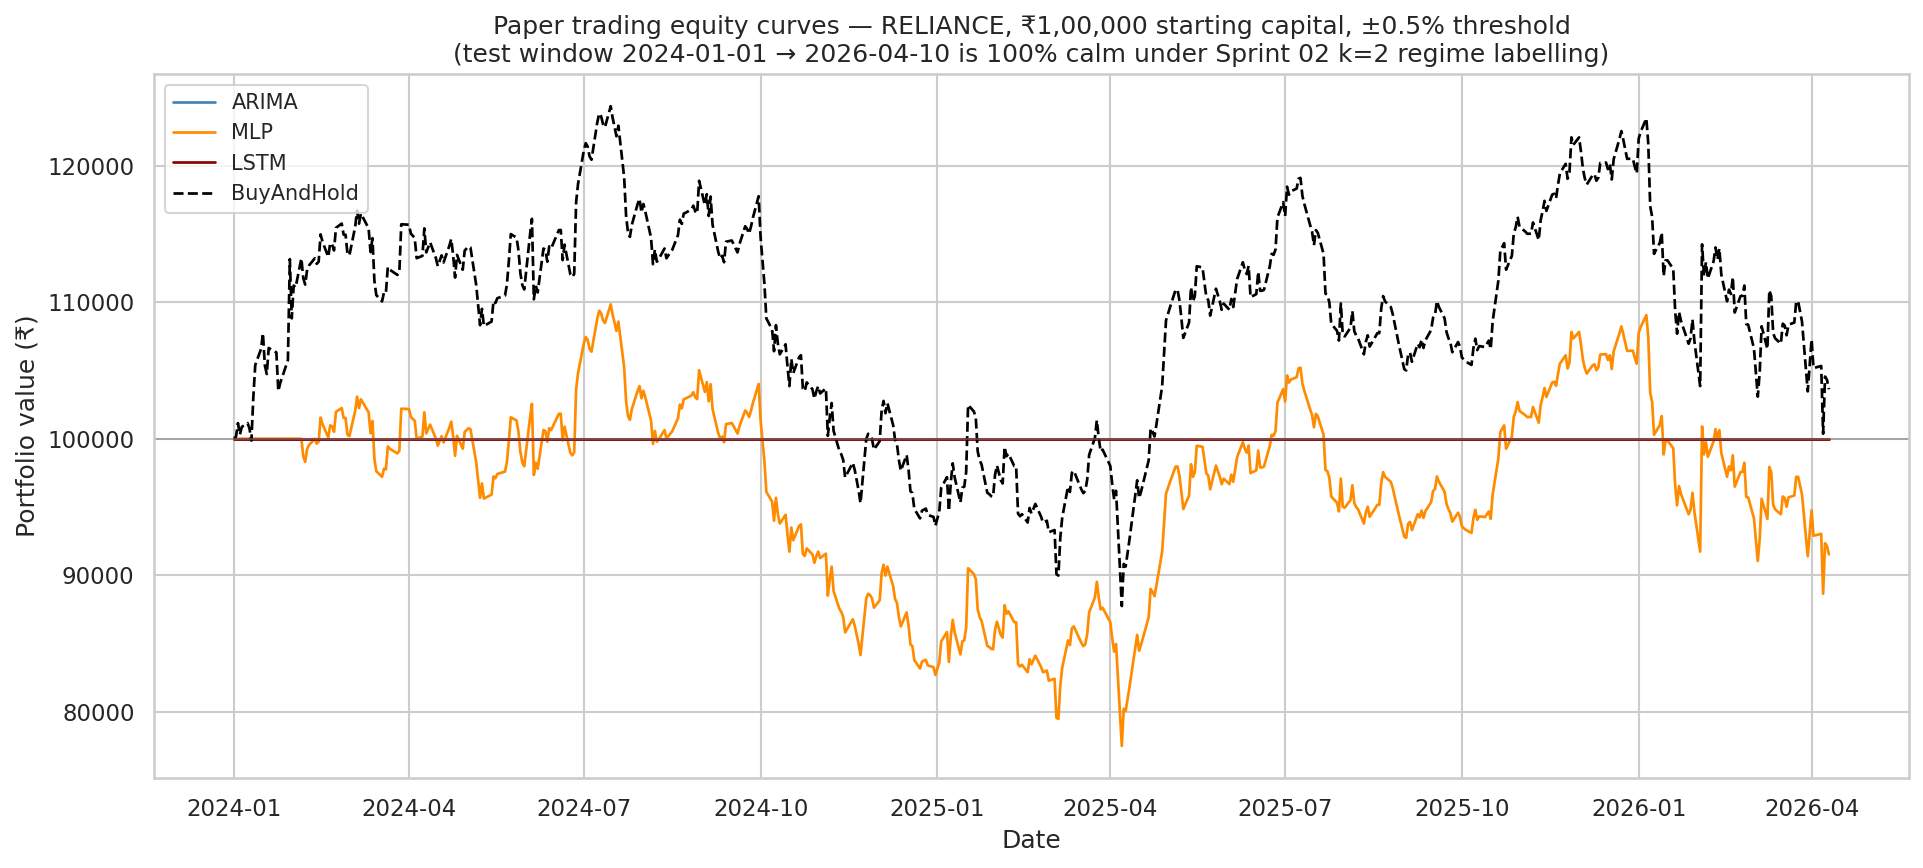

In [22]:
display(Image(filename=str(FIGURES / "equity_curves.png")))


**Headline: buy-and-hold wins.** BuyAndHold ends at +3.62%; ARIMA and LSTM never trade and finish flat at 0.00%; MLP fires once on 2024-02-05, holds into the trough, and ends at **−8.47%**.

**Why ARIMA and LSTM never trade — the prediction-σ-vs-threshold mismatch.** The ±0.5% threshold is asking the model for a confident directional call. What the models actually produce on the test window:

| model | predicted log-return std | range | crossings of ±0.005 |
|---|---|---|---|
| ARIMA(0,0,0) | 0 | constant +0.0009 | 0 |
| LSTM | 5e-5 | [+0.00050, +0.00086] | 0 |
| MLP | 0.00127 | [-0.00403, +0.00619] | 6 (all BUY) |
| (realised) | 0.01373 | [-0.078, +0.078] | 200+ |

The realised σ is an order of magnitude larger than every model's predicted σ. ARIMA is literally a constant; the LSTM has collapsed to a near-flat ribbon; the MLP has the widest prediction band but still only crosses the threshold 6 times. The first MLP BUY consumes all cash so the next five are no-ops; the position is held into the drawdown that produces the −8.47%.

This is the **same noise-floor story** that §4 told in RMSE/DA terms, now in P&L. The threshold filter is correctly rejecting un-actionable predictions on ARIMA and LSTM — a model firing hundreds of trades on near-zero edges would be worse than the zero-trade outcome, not better. The MLP gets the worst of both worlds: just enough confidence to fire once at the wrong moment.

**Notes on the Sharpe column.** Sharpe is NaN for ARIMA and LSTM because zero trades → zero return variance → undefined denominator. Buy-and-hold's own Sharpe is faintly negative (−0.089) because the 6.5% T-bill risk-free rate is well above RELIANCE-only's 1.6% annualised return over this 27-month stretch — the ratio reflects that, not a model failure. Win rate is NaN across the board because no SELL ever fired (zero completed round-trips).


## 8. Conclusion

### What worked

- The classical Box-Jenkins workflow ran end-to-end on seven tickers without surprises. Stationarity tests gave a clean unanimous result on log returns; `auto_arima` cross-checked the manual orders and trimmed where appropriate; residual diagnostics were thorough enough to identify their own limitation (variance structure left on the table) and motivate GARCH organically.
- GARCH(1, 1) fit cleanly with α + β ≈ 0.95 — textbook persistence for an Indian large cap. The drift parameter agreed with ARIMA's to three significant figures, which is a nice internal consistency check.
- Walk-forward evaluation across all models was apples-to-apples (562 one-step-ahead steps, identical test window, identical metrics) which made the §6 master table genuinely comparable.
- The Diebold-Mariano test gave the right epistemic answer — a small RMSE edge is **not** a real forecast-accuracy difference. Better to know.

### What didn't

- Five of seven tickers landed at ARIMA(0, 0, 0). The honest read: daily log returns are very close to white noise at this horizon, and the linear-Gaussian-mean models the course covers cannot extract much.
- The k-means regime detector found one regime — COVID — and called everything else calm. The directive's regime-split benchmark is consequently degenerate on the test window. Reported honestly rather than re-labelled to fit the spec.
- Normal-GARCH underestimates the tails (max |return| 0.078 vs max σ_t 0.029). The §2.4 Q-Q plot warned about this; the GARCH summary confirmed it on the test window.
- Paper trading: buy-and-hold beat every model. The ±0.5% threshold is well beyond the prediction-σ of any of these models, so they either never trade (ARIMA, LSTM) or trade once at the wrong time (MLP).

### Limitations

- **Single-asset paper trading.** Only RELIANCE traded; no portfolio construction across the seven tickers; no risk budget; no transaction costs or slippage. Realistic versions of any of these would make the picture worse, not better.
- **Daily horizon.** Most of the structure in equity returns lives at intraday or weekly horizons, not daily. The Box-Jenkins workflow would have more to chew on at the weekly horizon (or with macro exogenous variables) than it does on raw daily log returns.
- **No exogenous regressors.** The ARIMA models are univariate. Adding NSEI/SENSEX returns as exogenous predictors (ARIMAX) is the obvious classical extension and is not done here.
- **Look-ahead caveats.** Time-based train/val/test split, scaler fit on train only, walk-forward forecasts. The k-means regime detector is fit on the full series (used only as a labelling tool, not a predictive feature) — a stricter setup would refit it expanding-window. Flagged.

### What I'd do differently with more time

- **Student-t or skew-t GARCH** to handle the fat tails properly. One-line change in the `arch` config; non-trivial effect on the extreme-return story.
- **ARIMAX** with NSEI / SENSEX or sector-index returns as exogenous regressors. The cross-correlations in §2.7 say the contemporaneous linkage is real; whether it has predictive content at h = 1 is a different question.
- **Wider `auto_arima` search radius.** The Ljung-Box failure on RELIANCE residuals at lags 10/20 hints at structure beyond max_p = max_q = 5. Worth checking.
- **Re-label regimes** with percentile bands on rolling vol so the test window has *some* turbulent days, making §6's regime split non-degenerate. Or move to a Hamilton-style Markov-switching model and let the regime structure be inferred.
- **FinBERT** instead of VADER for sentiment (handled in `aiml/notebook.ipynb`'s sentiment section, not here).

### Closing

The headline finding for this course's submission is that the classical time-series toolkit, applied honestly, gave a clear answer: **daily Indian-equity log returns are close to white noise, with strong heteroskedasticity and fat tails, and the linear-Gaussian models that the course covers cannot extract a directional edge at the daily horizon under realistic walk-forward conditions.** That's the kind of negative result a learning project should be willing to write down.

Source code: `scripts/01_eda.py` through `scripts/10_sentiment.py`. Sprint reports: `results/reports/01_eda.md` through `10_sentiment.md`.
